# Task A — Exploratory Data Analysis: SMAP Telemetry
> **BAFAD Accelerated Research Track · Fall 2026**

In this notebook you will explore a sample of telemetry data drawn from NASA's Soil Moisture Active Passive (SMAP) satellite — the same dataset used in the BAFAD anomaly-detection research project.

**Your job:** Complete every cell marked `# YOUR CODE HERE`. Read the instructions carefully; output cells show what a correct result looks like.

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## 1 · Setup and Data Loading

Run this cell as-is — it loads all required libraries and reads the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Fixed style matching STAT 270 colour scheme
NAVY  = '#021B3A'
BLUE  = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

# Load the sample dataset
df = pd.read_csv('../data/smap_sample.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Loaded: 500 rows × 27 columns


## 2 · First Look at the Data

**A. (2 pts)** Use `.info()` and `.describe()` to inspect the dataset. In the markdown cell below, answer:
- How many telemetry channels are there?
- What does the `anomaly` column represent?
- Are there any missing values?

**Your answer (2–4 sentences):**

There are 25 telemetry channels in the dataset, from chan_00 through chan_24. The anomaly column represents whether a timestep is normal or has been labeled as an anomaly. There are no missing values in the dataset.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  500 non-null    int64  
 1   chan_00    500 non-null    float64
 2   chan_01    500 non-null    float64
 3   chan_02    500 non-null    float64
 4   chan_03    500 non-null    float64
 5   chan_04    500 non-null    float64
 6   chan_05    500 non-null    float64
 7   chan_06    500 non-null    float64
 8   chan_07    500 non-null    float64
 9   chan_08    500 non-null    float64
 10  chan_09    500 non-null    float64
 11  chan_10    500 non-null    float64
 12  chan_11    500 non-null    float64
 13  chan_12    500 non-null    float64
 14  chan_13    500 non-null    float64
 15  chan_14    500 non-null    float64
 16  chan_15    500 non-null    float64
 17  chan_16    500 non-null    float64
 18  chan_17    500 non-null    float64
 19  chan_18    500 non-null    float64
 20  chan_19   

,timestamp,chan_00,chan_01,chan_02,chan_03,chan_04,chan_05,chan_06,chan_07,chan_08,...,chan_16,chan_17,chan_18,chan_19,chan_20,chan_21,chan_22,chan_23,chan_24,anomaly
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,15030.000000,0.014707,0.012190,0.028274,0.019272,0.007134,-0.001609,-0.008584,-0.008491,-0.021960,...,0.039780,0.022125,0.033303,0.023156,0.019360,-0.002823,-0.014540,-0.044000,-0.039156,0.04800
std,8668.909966,0.356819,0.419378,0.437221,0.429701,0.481541,0.463448,0.479479,0.515423,0.533819,...,0.709725,0.732462,0.740952,0.760108,0.792660,0.846386,0.822671,0.865636,0.871447,0.21398
min,60.000000,-0.588100,-3.564040,-0.654510,-0.714480,-3.257240,-0.757030,-0.854760,-0.855550,-0.837470,...,-1.113290,-3.030020,-1.119810,-1.173830,-1.148730,-5.019940,-1.295860,-3.643910,-1.314230,0.00000
25%,7545.000000,-0.328545,-0.368602,-0.365287,-0.394363,-0.426525,-0.455228,-0.478065,-0.508625,-0.559280,...,-0.676052,-0.690743,-0.710070,-0.722268,-0.750848,-0.757110,-0.814723,-0.860980,-0.913103,0.00000
50%,15030.000000,0.037820,0.042780,0.032710,0.038110,0.051000,0.009465,-0.019030,-0.004145,-0.059320,...,0.050270,0.058320,0.082505,0.037025,0.048545,-0.000495,-0.036935,-0.080565,-0.085385,0.00000
75%,22515.000000,0.365538,0.387972,0.418593,0.420992,0.443580,0.458758,0.456877,0.475345,0.516820,...,0.723555,0.732325,0.766210,0.780995,0.756782,0.783923,0.800028,0.833910,0.816553,0.00000
max,30000.000000,0.616390,0.619560,3.338690,2.139420,3.036740,0.764780,0.771170,2.468480,0.827830,...,3.524870,1.118980,1.125470,1.184130,4.287770,3.879340,1.252730,1.264990,1.323300,1.00000


## 3 · Anomaly Prevalence

**B. (3 pts)** Compute the number and percentage of timesteps labelled as anomalies (`anomaly == 1`).
Print a sentence like: *'X of 500 timesteps are anomalies (Y.Y%).'*

In [5]:
# YOUR CODE HERE
n_anomaly = (df['anomaly'] == 1).sum()
pct = n_anomaly / len(df) * 100
print(f'{n_anomaly} of {len(df)} timesteps are anomalies ({pct:.1f}%).')

24 of 500 timesteps are anomalies (4.8%).


## 4 · Time-Series Visualisation

**C. (5 pts)** Plot `chan_00` (y-axis) against `timestamp` (x-axis) as a line chart.
- Use `NAVY` for normal timesteps and mark anomalies as red scatter points (`'r.'`, size 8).
- Label axes and add a title: *'SMAP Channel 00 — Telemetry with Anomalies Highlighted'*.
- Apply `plt.tight_layout()`.

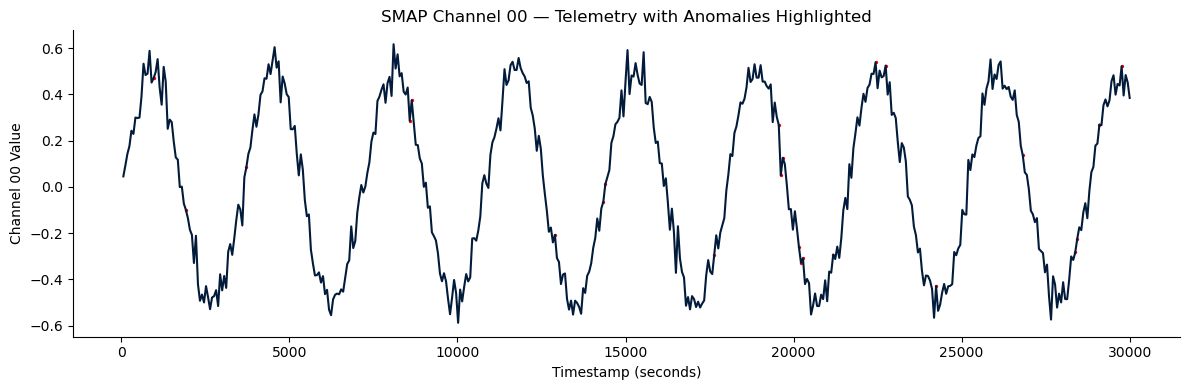

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df['timestamp'], df['chan_00'], color=NAVY)

anomaly_points = df[df['anomaly'] == 1]

ax.scatter(
    anomaly_points['timestamp'],
    anomaly_points['chan_00'],
    color='r',
    marker='.',
    s=8
)

ax.set_xlabel('Timestamp (seconds)')
ax.set_ylabel('Channel 00 Value')
ax.set_title('SMAP Channel 00 — Telemetry with Anomalies Highlighted')
plt.tight_layout()
plt.show()

## 5 · Multi-Channel Heatmap

**D. (5 pts)** Create a heatmap showing all 25 telemetry channels over time.
- Rows = channels (`chan_00` … `chan_24`), columns = timesteps.
- Use `plt.imshow()` with `aspect='auto'`, `cmap='RdBu_r'`, and `vmin=-2, vmax=2`.
- Add a colourbar labelled *'Normalised Value'*.
- Draw a thin red vertical line at each anomaly timestamp.

*Hint:* Extract channel columns with `df.filter(like='chan_')`. Transpose so channels are on the y-axis.

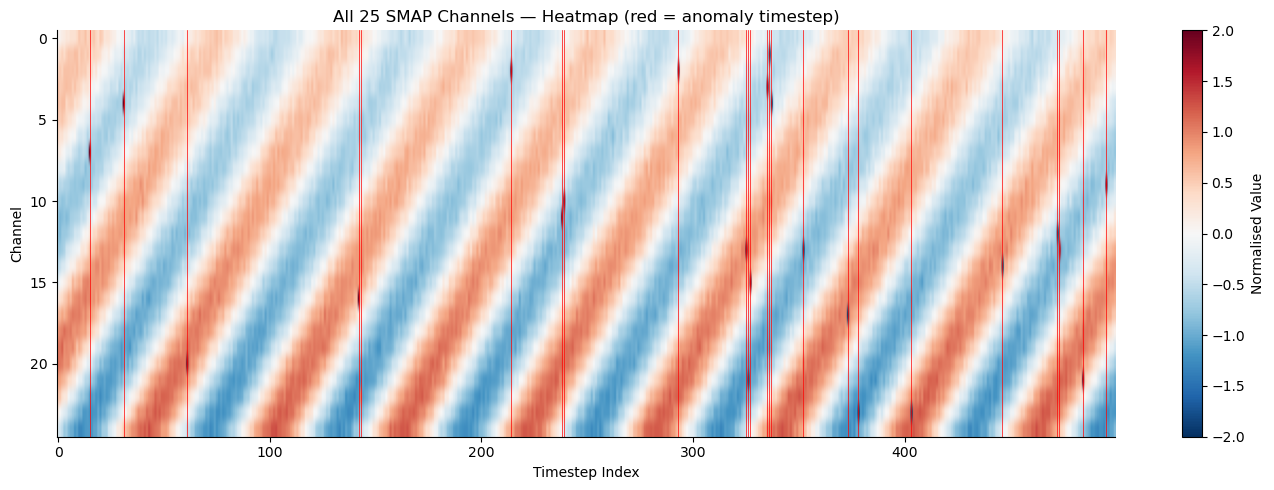

In [7]:
chan_cols = df.filter(like='chan_').columns.tolist()
data_matrix = df[chan_cols].values.T  # shape: (25 channels, 500 timesteps)

fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(
    data_matrix,
    aspect='auto',
    cmap='RdBu_r',
    vmin=-2,
    vmax=2
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Normalised Value')

for x in df.index[df['anomaly'] == 1]:
    ax.axvline(x, color='red', linewidth=0.5)
    
ax.set_xlabel('Timestep Index')
ax.set_ylabel('Channel')
ax.set_title('All 25 SMAP Channels — Heatmap (red = anomaly timestep)')
plt.tight_layout()
plt.show()

## 6 · Distribution of Channel Values

**E. (5 pts)** For `chan_00`, plot a histogram of values for **normal** timesteps vs **anomaly** timesteps side-by-side (use `alpha=0.6`).
- Use `NAVY` for normal, `BLUE` for anomaly.
- Add a legend and axis labels.

What do you notice about the two distributions?

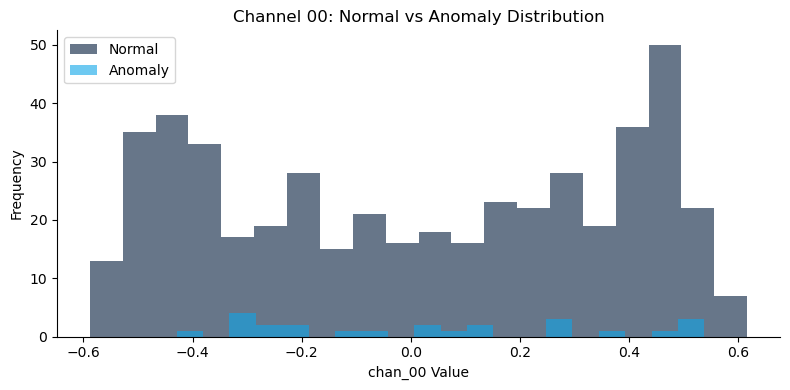

In [8]:
normal  = df[df['anomaly'] == 0]['chan_00']
anomaly = df[df['anomaly'] == 1]['chan_00']

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(normal, bins=20, alpha=0.6, color=NAVY, label='Normal')
ax.hist(anomaly, bins=20, alpha=0.6, color=BLUE, label='Anomaly')

ax.set_xlabel('chan_00 Value')
ax.set_ylabel('Frequency')
ax.set_title('Channel 00: Normal vs Anomaly Distribution')
ax.legend()
plt.tight_layout()
plt.show()

**Your observation:**

The normal values make up most of the distribution, while the anomaly values are much less common. The anomaly values appear to overlap with some of the normal values, but there are fewer anomaly observations overall.


## 7 · Reflection (2 pts)

Answer in the cell below (3–5 sentences total):

1. What surprised you most about the SMAP telemetry data?
2. How might the EDA patterns you observed here guide the design of an anomaly-detection model?

**Your reflection:**

What surprised me most was that only a small percentage of the timesteps were labeled as anomalies. The heatmap also showed that the telemetry values can change across different channels and over time. These patterns could help an anomaly-detection model learn what normal behavior looks like. The model could then identify values or patterns that are different from the normal data.
